In [ ]:
import random

import altair as alt
import marimo as mo
import numpy as np
import polars as pl
from scipy import stats

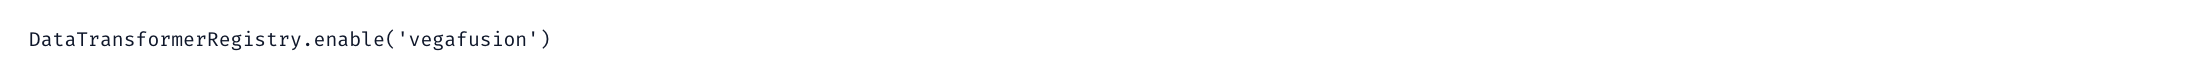

In [ ]:
alt.data_transformers.enable("vegafusion")

In [ ]:
# Print util function
def marimo_print(object):
    with mo.redirect_stdout():
        print(object)

In [ ]:
# Data util function
def sample_binomial_distribution(n: int, p: float, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed=seed)
    return rng.binomial(1, p, size=n)

## Benefits of Bayesian Methods
1. Point-estimates include the entire distribution.
2. Works with small amounts of data.
3. Can incorporate priors to improve estimates.

## Example Configurations
1. Uniform prior (alpha and beta are 1).
2. Informed prior (alpha = 2 and beta = 100).
3. Small sample sizes.
4. Unequal sample sizes.

## Inputs

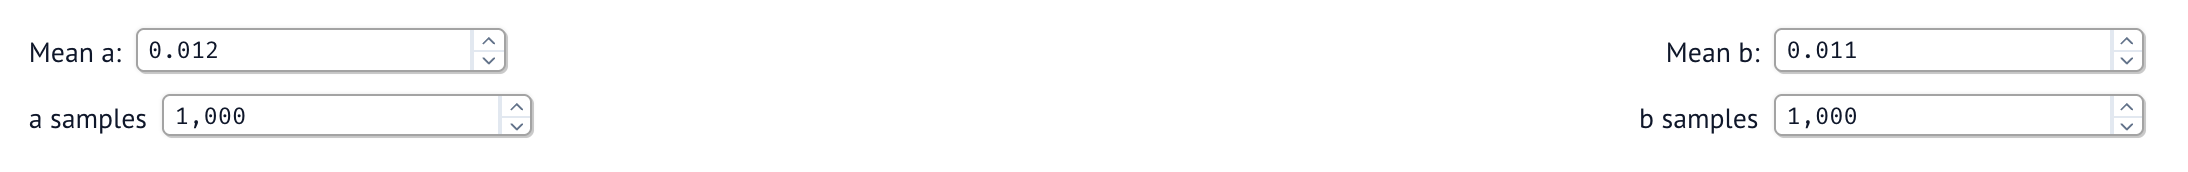

In [ ]:
true_mean_a_input = mo.ui.number(start=0, stop=1, value=0.012, label="Mean a:")
true_mean_b_input = mo.ui.number(start=0, stop=1, value=0.011, label="Mean b:")

n_a_input = mo.ui.number(
    start=0, stop=1_000_000, value=1000, step=1, label="a samples"
)
n_b_input = mo.ui.number(
    start=0, stop=1_000_000, value=1000, step=1, label="b samples"
)

mo.vstack(
    [
        mo.hstack([true_mean_a_input, true_mean_b_input]),
        mo.hstack([n_a_input, n_b_input]),
    ]
)

In [ ]:
true_mean_a = true_mean_a_input.value
true_mean_b = true_mean_b_input.value

n_a = n_a_input.value
n_b = n_b_input.value

## Priors

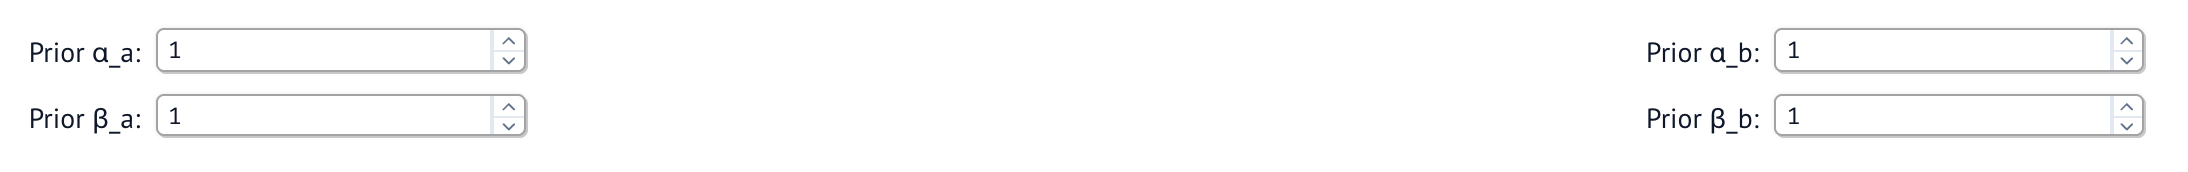

In [ ]:
prior_alpha_a_input = mo.ui.number(
    start=0.01, stop=100, value=1, label="Prior α_a:"
)
prior_beta_a_input = mo.ui.number(start=0.01, stop=100, value=1, label="Prior β_a:")
prior_alpha_b_input = mo.ui.number(
    start=0.01, stop=100, value=1, label="Prior α_b:"
)
prior_beta_b_input = mo.ui.number(start=0.01, stop=100, value=1, label="Prior β_b:")

mo.vstack(
    [
        mo.hstack([prior_alpha_a_input, prior_alpha_b_input]),
        mo.hstack([prior_beta_a_input, prior_beta_b_input]),
    ]
)

In [ ]:
prior_alpha_a = prior_alpha_a_input.value
prior_beta_a = prior_beta_a_input.value
prior_alpha_b = prior_alpha_b_input.value
prior_beta_b = prior_beta_b_input.value

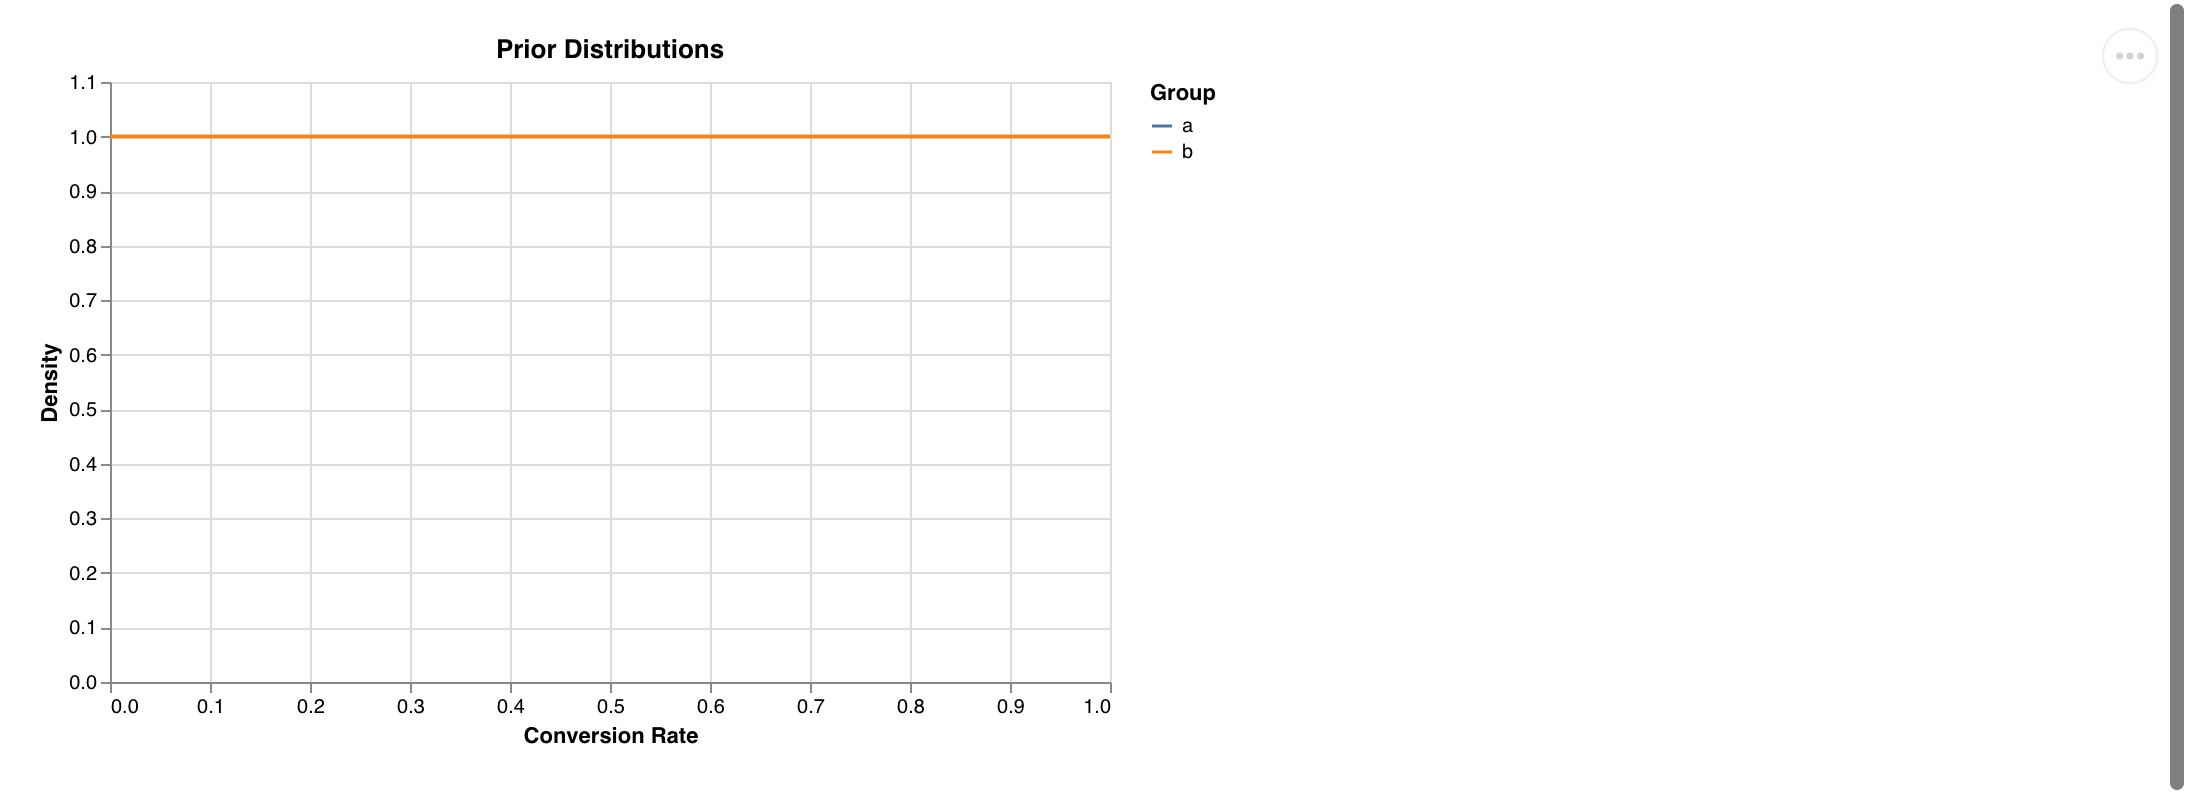

In [ ]:
def prior_pdf(alpha, beta, n_points=500):
    prior = stats.beta(alpha, beta)
    mean = prior.mean()
    std = prior.std()
    x = np.linspace(max(0, mean - 4 * std), min(1, mean + 4 * std), n_points)
    return x, prior.pdf(x)

x_prior_a, pdf_prior_a = prior_pdf(prior_alpha_a, prior_beta_a)
x_prior_b, pdf_prior_b = prior_pdf(prior_alpha_b, prior_beta_b)

prior_df = pl.concat(
    [
        pl.DataFrame({"group": "a", "x": x_prior_a, "density": pdf_prior_a}),
        pl.DataFrame({"group": "b", "x": x_prior_b, "density": pdf_prior_b}),
    ]
)

(
    alt.Chart(prior_df, title="Prior Distributions")
    .mark_line()
    .encode(
        x=alt.X("x:Q", title="Conversion Rate"),
        y=alt.Y("density:Q", title="Density"),
        color=alt.Color("group:N", title="Group"),
    )
    .properties(width=500, height=300)
)

## Data

In [ ]:
group_a = sample_binomial_distribution(n=n_a, p=true_mean_a, seed=42)
group_b = sample_binomial_distribution(n=n_b, p=true_mean_b, seed=43)

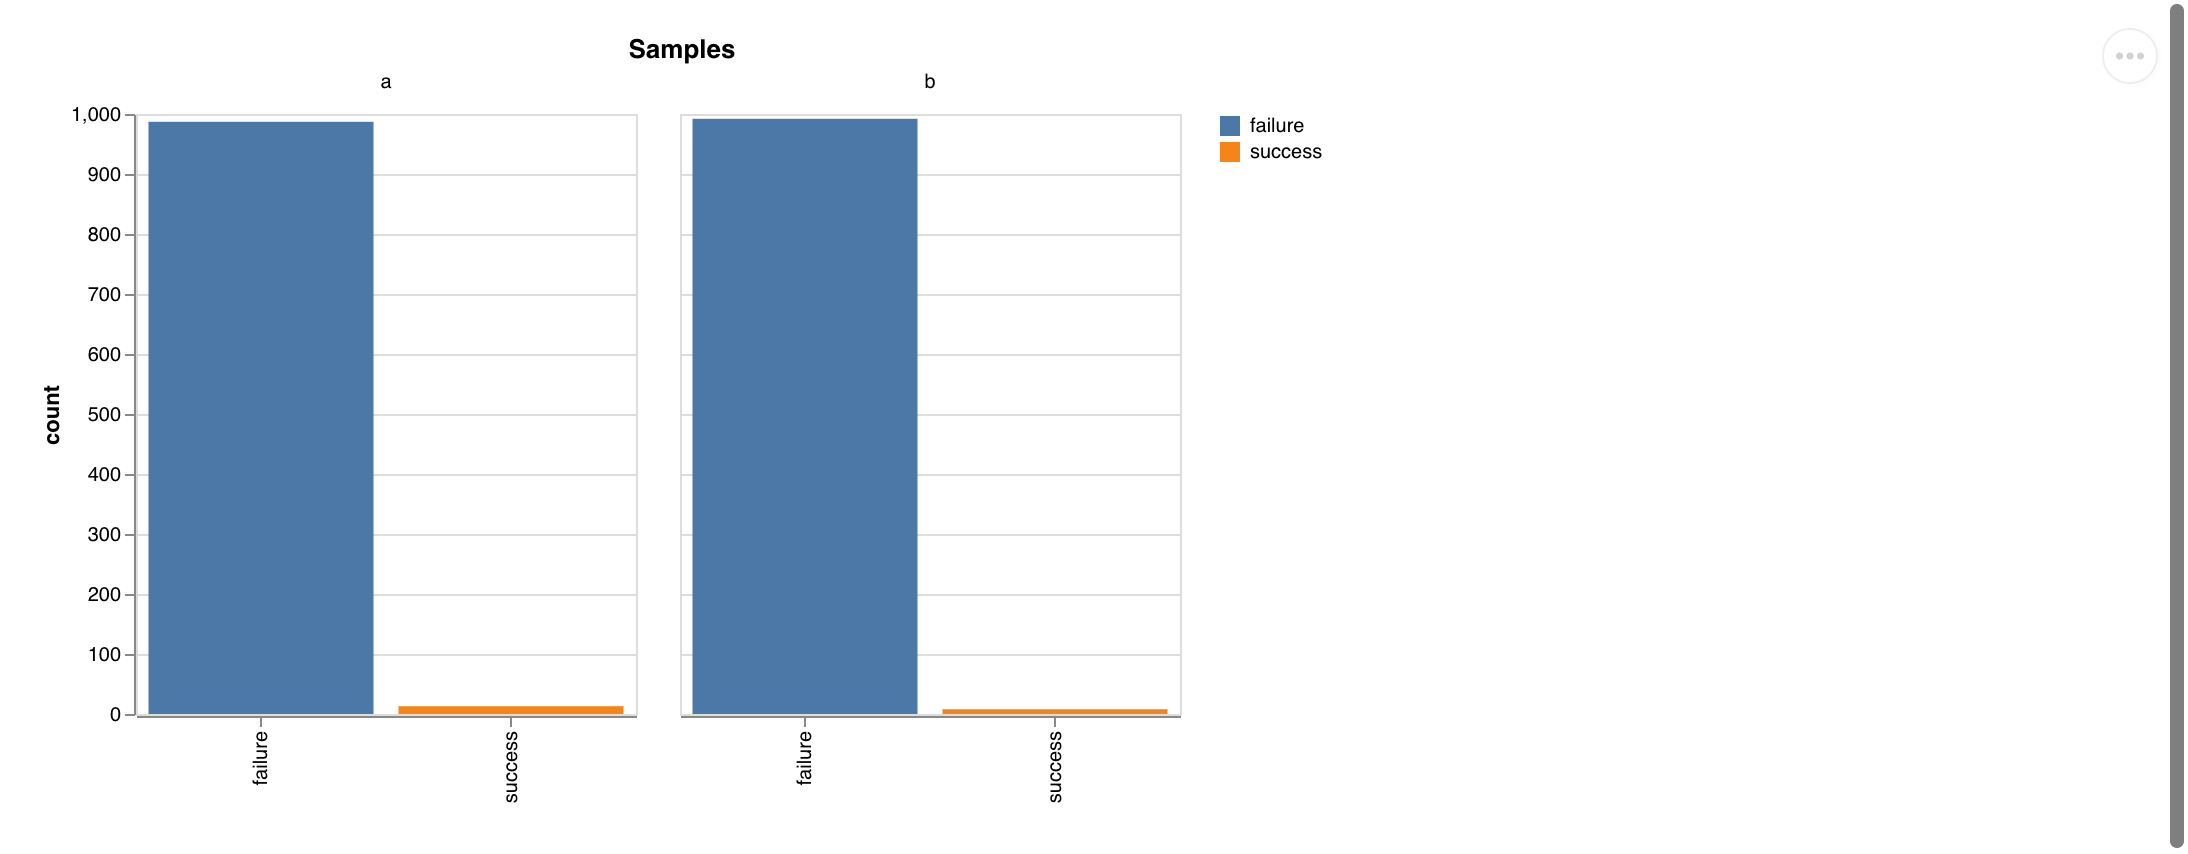

In [ ]:
successes_a = group_a.sum()
successes_b = group_b.sum()

failures_a = len(group_a) - successes_a
failures_b = len(group_b) - successes_b

samples_df = pl.DataFrame(
    {
        "group": ["a", "a", "b", "b"],
        "type": ["success", "failure", "success", "failure"],
        "count": [successes_a, failures_a, successes_b, failures_b],
    }
)

(
    alt.Chart(samples_df, title="Samples")
    .mark_bar()
    .encode(
        x=alt.X("type:N", title=""),
        y=alt.Y("count:Q"),
        color=alt.Color("type:N", title=""),
        column=alt.Column("group:N", title=""),
    )
    .properties(width=250, height=300)
    .configure_title(anchor='middle')
)

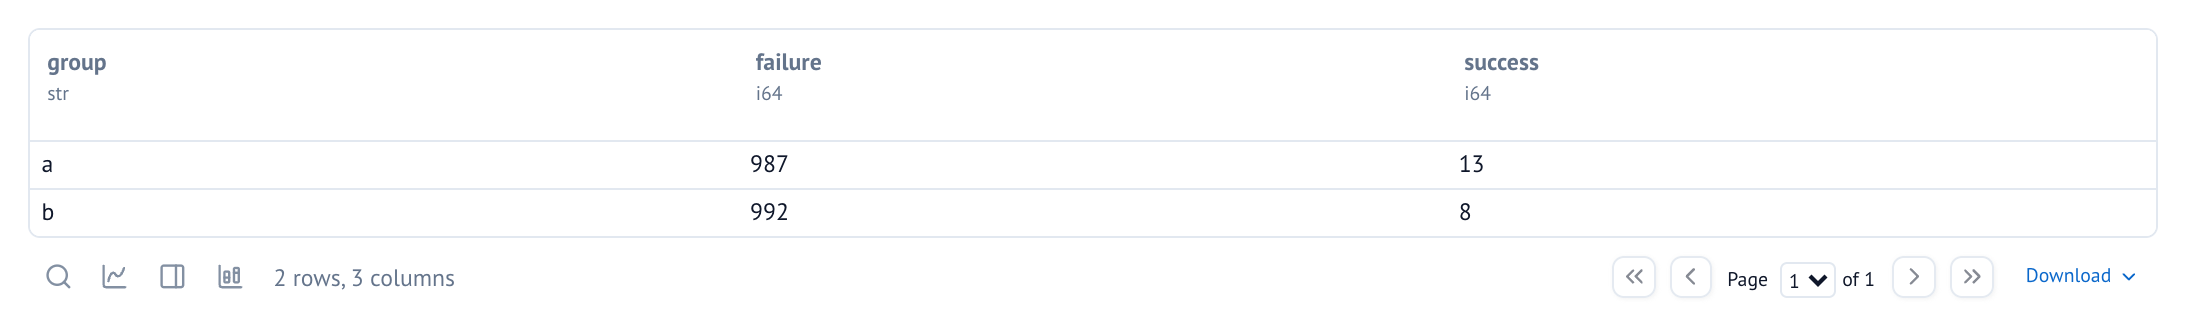

In [ ]:
samples_df.sort("type").pivot(index="group", on="type", values="count")

## Estimation

In [ ]:
def beta_posterior_pdf(group: np.ndarray, prior_alpha: float, prior_beta: float, n_points: int = 500):
    successes = group.sum()
    failures = len(group) - successes

    posterior_alpha = prior_alpha + successes
    posterior_beta = prior_beta + failures

    posterior = stats.beta(posterior_alpha, posterior_beta)

    mean = posterior.mean()
    std = posterior.std()

    x = np.linspace(max(0, mean - 4 * std), min(1, mean + 4 * std), n_points)
    pdf_values = posterior.pdf(x)

    max_idx = np.argmax(pdf_values)
    map_estimate = x[max_idx]

    return x, pdf_values, map_estimate, pdf_values[max_idx]

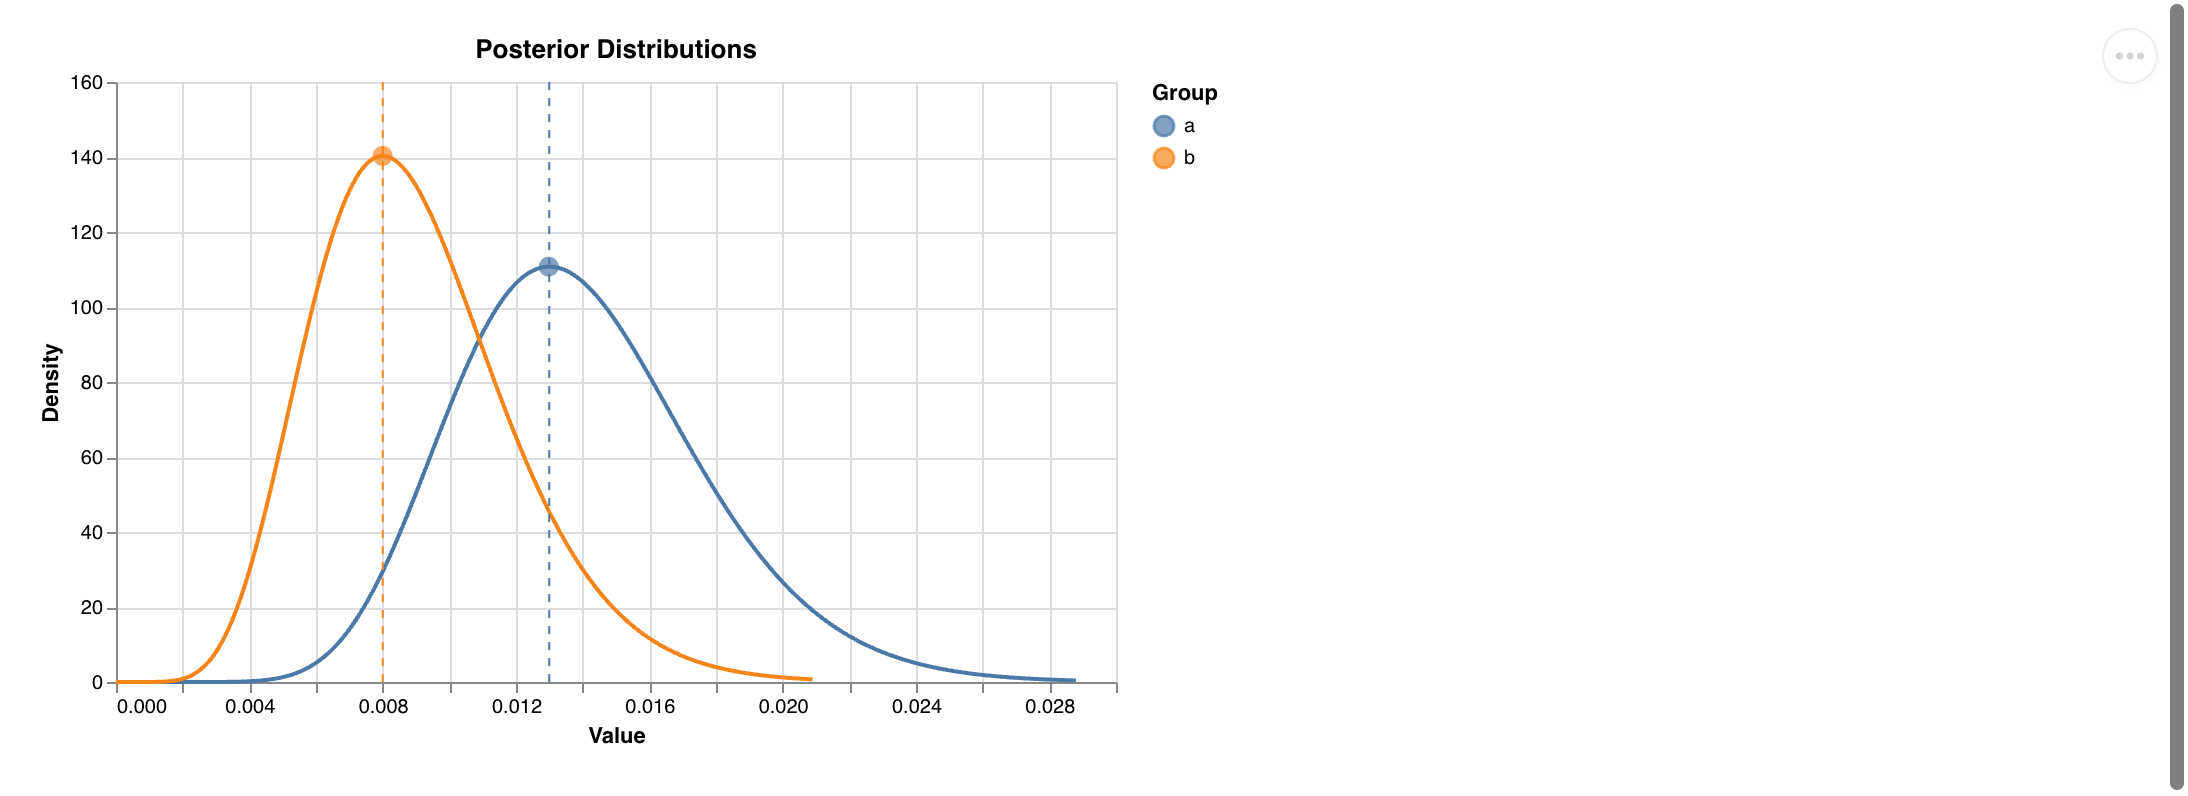

In [ ]:
x_a, pdf_a, map_a, map_density_a = beta_posterior_pdf(
    group_a, prior_alpha_a, prior_beta_a
)
x_b, pdf_b, map_b, map_density_b = beta_posterior_pdf(
    group_b, prior_alpha_b, prior_beta_b
)

posterior_df = pl.concat(
    [
        pl.DataFrame({"group": "a", "x": x_a, "density": pdf_a}),
        pl.DataFrame({"group": "b", "x": x_b, "density": pdf_b}),
    ]
)

map_df = pl.DataFrame(
    {
        "group": ["a", "b"],
        "x": [map_a, map_b],
        "density": [map_density_a, map_density_b],
    }
)

sample_mean_a = group_a.mean()
sample_mean_b = group_b.mean()

sample_mean_df = pl.DataFrame(
    {"group": ["a", "b"], "x": [sample_mean_a, sample_mean_b]}
)

lines = (
    alt.Chart(posterior_df)
    .mark_line()
    .encode(
        x=alt.X("x:Q", title="Value"),
        y=alt.Y("density:Q", title="Density"),
        color=alt.Color("group:N", title="Group"),
    )
)

points = (
    alt.Chart(map_df)
    .mark_point(size=100, filled=True)
    .encode(x="x:Q", y="density:Q", color="group:N")
)

sample_means = (
    alt.Chart(sample_mean_df)
    .mark_rule(strokeDash=[4, 4])
    .encode(x="x:Q", color="group:N")
)

(lines + points + sample_means).properties(
    width=500, height=300, title="Posterior Distributions"
)

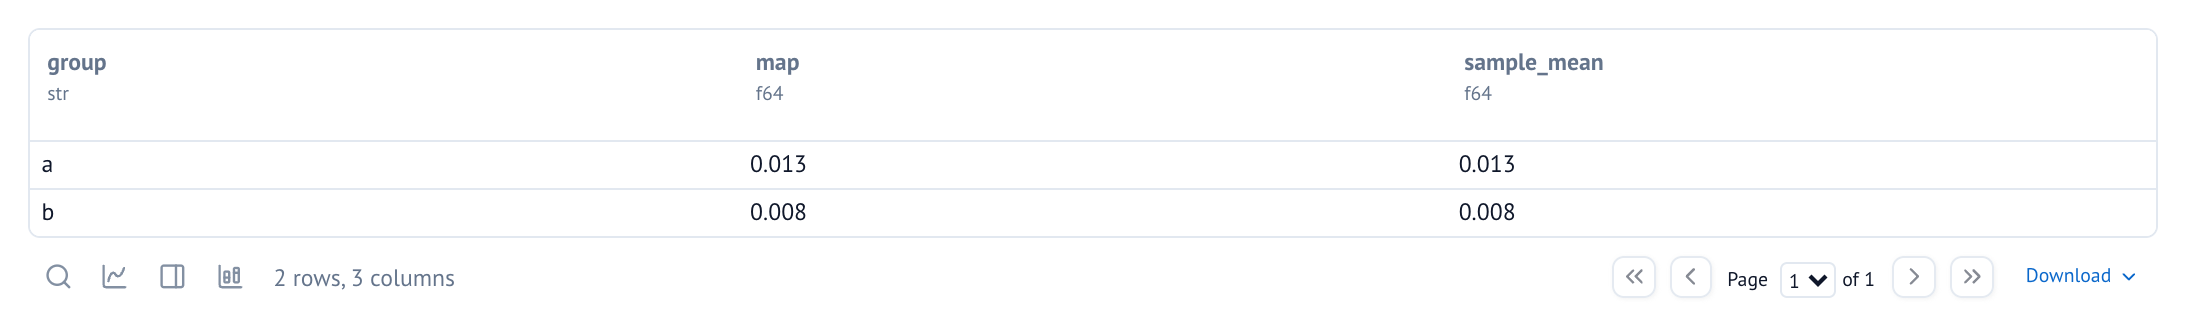

In [ ]:
(
    pl.DataFrame(
        {
            "group": ["a", "b"],
            "map": [map_a, map_b],
            "sample_mean": [sample_mean_a, sample_mean_b],
        }
    ).with_columns(pl.exclude("group").round(4))
)

## Statistical Significance
Is a > b?

In [ ]:
def two_proportion_ztest(group_a: np.ndarray, group_b: np.ndarray):
    p_a, p_b = group_a.mean(), group_b.mean()
    n_a, n_b = len(group_a), len(group_b)

    p_pooled = (group_a.sum() + group_b.sum()) / (n_a + n_b)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_a + 1 / n_b))

    z_stat = (p_a - p_b) / se if se > 0 else 0

    # One-sided test: P(A > B)
    return stats.norm.sf(z_stat)

In [ ]:
def probability_test(
    group_a: np.ndarray,
    group_b: np.ndarray,
    prior_alpha_a=1,
    prior_beta_a=1,
    prior_alpha_b=1,
    prior_beta_b=1,
    seed=42,
):
    rng = np.random.default_rng(seed)

    alpha_a = prior_alpha_a + group_a.sum()
    beta_a = prior_beta_a + len(group_a) - group_a.sum()

    alpha_b = prior_alpha_b + group_b.sum()
    beta_b = prior_beta_b + len(group_b) - group_b.sum()

    samples_a = stats.beta(alpha_a, beta_a).rvs(100_000, random_state=rng)
    samples_b = stats.beta(alpha_b, beta_b).rvs(100_000, random_state=rng)

    return (samples_a > samples_b).mean()

In [ ]:
pvalue_a_better = two_proportion_ztest(group_a, group_b)
prob_a_better = probability_test(
    group_a, group_b, prior_alpha_a, prior_beta_a, prior_alpha_b, prior_beta_b
)

In [ ]:
def interpret_frequentist(pvalue: float, alpha: float = 0.05):
    if pvalue < alpha:
        result = f"We reject the null hypothesis (p = {pvalue:.4f} < {alpha}). There is statistically significant evidence that A > B."
    else:
        result = f"We fail to reject the null hypothesis (p = {pvalue:.4f} >= {alpha}). There is no statistically significant evidence that A > B."
    return mo.md(f"**Frequentist:** {result}")

def interpret_bayesian(prob: float):
    return mo.md(
        f"**Bayesian:** There is a {prob * 100:.1f}% probability that A > B."
    )

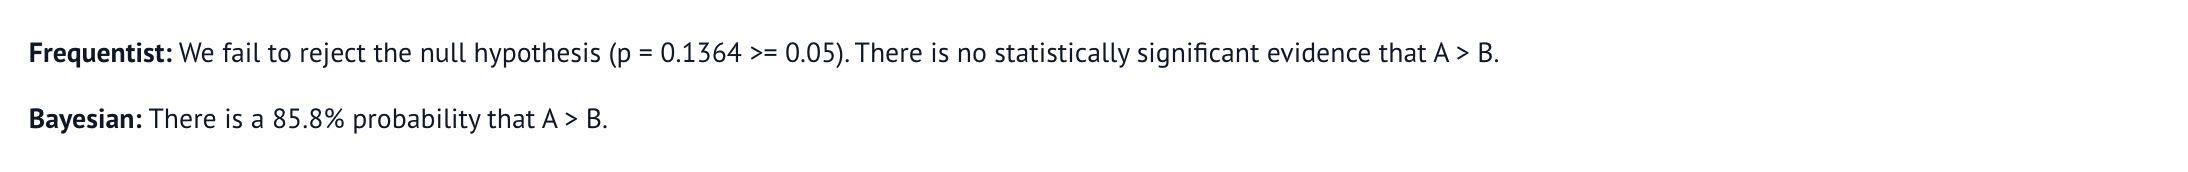

In [ ]:
mo.vstack(
    [interpret_frequentist(pvalue_a_better), interpret_bayesian(prob_a_better)]
)